## Task 1 —> Data Profiling & Duplicate Detection

1. Load the Social Media Sentiment dataset and display the number of rows and columns.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("sentimentdataset copy.csv")

print("Shape:", df.shape)
df.head()


Shape: (732, 15)


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


2. Shows column names, data types, and non-null counts all at once.

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    str    
 3   Sentiment     732 non-null    str    
 4   Timestamp     732 non-null    str    
 5   User          732 non-null    str    
 6   Platform      732 non-null    str    
 7   Hashtags      732 non-null    str    
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    str    
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), str(7)
memory usage: 225.0 KB


3. Find duplicate rows: `.duplicated()` checks whether a complete row is repeated. `.sum()` counts the duplicate rows.

In [4]:
print("Exact duplicate rows:", df.duplicated().sum())


Exact duplicate rows: 0


4. Check duplicate social-media posts using the main text field. This identifies repeated post text even when other metadata may differ.

In [5]:
post_duplicates = df.duplicated(subset=["Text"]).sum()
print("Duplicate posts by text:", post_duplicates)


Duplicate posts by text: 25


5. Remove unnecessary index columns. `Unnamed: 0.1` and `Unnamed: 0` are stored index columns rather than analytical features.

In [6]:
df = df.drop(columns=["Unnamed: 0.1", "Unnamed: 0"], errors="ignore")
print("Shape after removing index columns:", df.shape)


Shape after removing index columns: (732, 13)


## Task 2 — Missing Values & Data Quality

6. Create a missing-value report showing both the number and percentage of missing values in each column.

In [7]:
missing_count = df.isnull().sum()

missing_percent = (
    df.isnull().sum() / len(df)
) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent.round(2)
})

missing_report = missing_report[
    missing_report["Missing Count"] > 0
].sort_values(
    "Missing Count",
    ascending=False
)

print(missing_report)

if missing_report.empty:
    print("No missing values found.")


Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
No missing values found.


7. Check the unique values of the main categorical fields before cleaning. This helps identify extra spaces or inconsistent labels.

In [8]:
print("Raw Platform values:")
print(df["Platform"].unique())

print("\nNumber of raw Sentiment labels:", df["Sentiment"].nunique())


Raw Platform values:
<ArrowStringArray>
[' Twitter  ', ' Instagram ', ' Facebook ', ' Twitter ']
Length: 4, dtype: str

Number of raw Sentiment labels: 279


8. Check data types of all columns.

In [9]:
print(df.dtypes)


Text             str
Sentiment        str
Timestamp        str
User             str
Platform         str
Hashtags         str
Retweets     float64
Likes        float64
Country          str
Year           int64
Month          int64
Day            int64
Hour           int64
dtype: object


## Task 3 —> Data Cleaning

9. Remove extra spaces from all text/category columns. This is important because values such as `Twitter` and `Twitter ` should be treated as the same platform.

In [10]:
text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].str.strip()

print("Text columns cleaned successfully.")


Text columns cleaned successfully.


/var/folders/5x/xcp0cwgj27zb3ljw610qt91m0000gn/T/ipykernel_25598/3696960954.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include="object").columns


10. Convert the Timestamp column into a proper datetime format.

In [11]:
df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    errors="coerce"
)

print("Timestamp datatype:", df["Timestamp"].dtype)


Timestamp datatype: datetime64[us]


11. Create an Engagement column. Engagement is calculated as Likes + Retweets.

In [12]:
df["Engagement"] = df["Likes"] + df["Retweets"]

print(df[["Likes", "Retweets", "Engagement"]].head())


   Likes  Retweets  Engagement
0   30.0      15.0        45.0
1   10.0       5.0        15.0
2   40.0      20.0        60.0
3   15.0       8.0        23.0
4   25.0      12.0        37.0


12. Check the cleaned platform categories.

In [13]:
print("Clean Platform values:")
print(df["Platform"].unique())

print("\nPlatform counts:")
print(df["Platform"].value_counts())


Clean Platform values:
<ArrowStringArray>
['Twitter', 'Instagram', 'Facebook']
Length: 3, dtype: str

Platform counts:
Platform
Instagram    258
Twitter      243
Facebook     231
Name: count, dtype: int64


13. Check the cleaned sentiment categories. The dataset contains many emotion/sentiment labels, so the original labels are retained.

In [14]:
print("Number of unique sentiment labels:", df["Sentiment"].nunique())
print("\nTop 15 sentiment labels:")
print(df["Sentiment"].value_counts().head(15))


Number of unique sentiment labels: 191

Top 15 sentiment labels:
Sentiment
Positive       45
Joy            44
Excitement     37
Contentment    19
Neutral        18
Gratitude      18
Curiosity      16
Serenity       15
Happy          14
Despair        11
Nostalgia      11
Awe             9
Grief           9
Loneliness      9
Hopeful         9
Name: count, dtype: int64


## Task 4 — Statistical Analysis

14. Descriptive statistics for the numerical variables.

In [15]:
df.describe()


,Timestamp,Retweets,Likes,Year,Month,Day,Hour,Engagement
count,732,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,2020-12-08 21:37:38.196721,21.508197,42.901639,2020.471311,6.122951,15.497268,15.521858,64.409836
min,2010-05-15 15:30:00,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000,15.000000
25%,2019-03-08 17:27:30,17.750000,34.750000,2019.000000,3.000000,9.000000,13.000000,52.500000
50%,2021-09-20 14:30:00,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000,65.000000
75%,2023-02-26 11:48:45,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000,75.000000
max,2023-10-22 20:45:00,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000,120.000000
std,NaN,7.061286,14.089848,2.802285,3.411763,8.474553,4.113414,21.143994


15. Calculate important engagement statistics.

In [16]:
print("Average Likes:", round(df["Likes"].mean(), 2))
print("Median Likes:", df["Likes"].median())
print("Average Retweets:", round(df["Retweets"].mean(), 2))
print("Median Retweets:", df["Retweets"].median())
print("Average Engagement:", round(df["Engagement"].mean(), 2))
print("Median Engagement:", df["Engagement"].median())


Average Likes: 42.9
Median Likes: 43.0
Average Retweets: 21.51
Median Retweets: 22.0
Average Engagement: 64.41
Median Engagement: 65.0


16. Display the minimum and maximum values for Likes, Retweets, and Engagement.

In [17]:
print("Likes - Min:", df["Likes"].min(), "Max:", df["Likes"].max())
print("Retweets - Min:", df["Retweets"].min(), "Max:", df["Retweets"].max())
print("Engagement - Min:", df["Engagement"].min(), "Max:", df["Engagement"].max())


Likes - Min: 10.0 Max: 80.0
Retweets - Min: 5.0 Max: 40.0
Engagement - Min: 15.0 Max: 120.0


## Task 5 — Analyze Social Media Platforms

17. Count the number of posts available on each platform.

In [18]:
platform_counts = df["Platform"].value_counts()

print(platform_counts)


Platform
Instagram    258
Twitter      243
Facebook     231
Name: count, dtype: int64


18. Calculate the average Likes, Retweets, and Engagement for each platform.

In [19]:
platform_summary = df.groupby("Platform")[[
    "Likes",
    "Retweets",
    "Engagement"
]].mean().round(2)

print(platform_summary)


           Likes  Retweets  Engagement
Platform                              
Facebook   41.87     20.97       62.84
Instagram  45.09     22.60       67.69
Twitter    41.56     20.86       62.42


## Task 6 — Visualization

19. Number of posts by social-media platform. This bar chart compares the number of records across platforms.

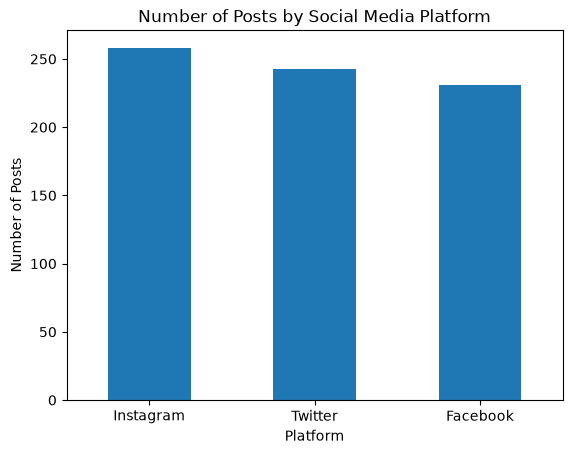

In [20]:
platform_counts.plot(kind="bar")

plt.title("Number of Posts by Social Media Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Posts")
plt.xticks(rotation=0)

plt.show()


20. Number of posts by year. This shows how the dataset is distributed across years.

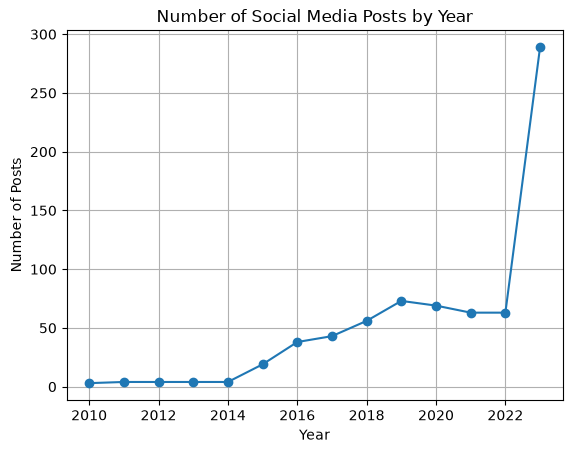

In [21]:
year_counts = df["Year"].value_counts().sort_index()

year_counts.plot(kind="line", marker="o")

plt.title("Number of Social Media Posts by Year")
plt.xlabel("Year")
plt.ylabel("Number of Posts")
plt.grid(True)

plt.show()


21. Distribution of Likes. This histogram shows how Likes are distributed in the dataset.

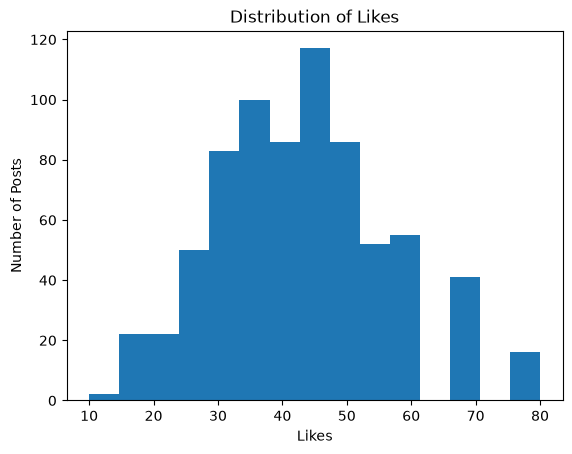

In [22]:
df["Likes"].plot(
    kind="hist",
    bins=15
)

plt.title("Distribution of Likes")
plt.xlabel("Likes")
plt.ylabel("Number of Posts")

plt.show()


22. Distribution of Retweets.

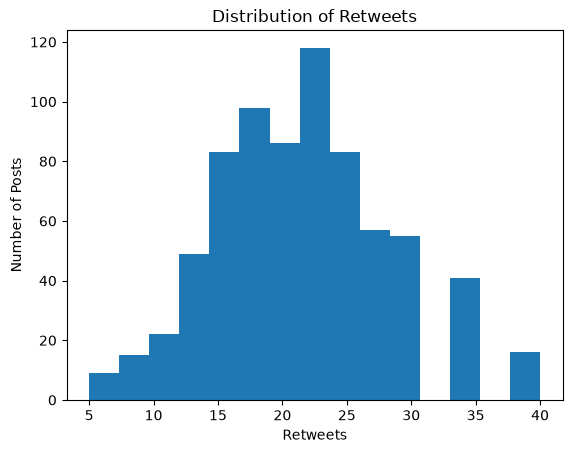

In [23]:
df["Retweets"].plot(
    kind="hist",
    bins=15
)

plt.title("Distribution of Retweets")
plt.xlabel("Retweets")
plt.ylabel("Number of Posts")

plt.show()


## Task 7 — Sentiment Analysis

23. Count the most frequent sentiment categories.

In [24]:
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts.head(15))


Sentiment
Positive       45
Joy            44
Excitement     37
Contentment    19
Neutral        18
Gratitude      18
Curiosity      16
Serenity       15
Happy          14
Despair        11
Nostalgia      11
Awe             9
Grief           9
Loneliness      9
Hopeful         9
Name: count, dtype: int64


24. Visualize the top 15 sentiment categories.

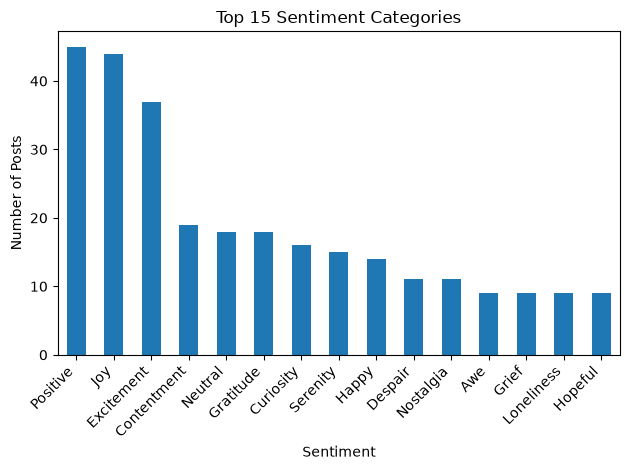

In [25]:
sentiment_counts.head(15).plot(kind="bar")

plt.title("Top 15 Sentiment Categories")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


25. Compare platforms across the top 10 sentiment categories.

In [26]:
top_sentiments = df["Sentiment"].value_counts().head(10).index

sentiment_platform = df[
    df["Sentiment"].isin(top_sentiments)
]

platform_sentiment_table = pd.crosstab(
    sentiment_platform["Platform"],
    sentiment_platform["Sentiment"]
)

print(platform_sentiment_table)


Sentiment  Contentment  Curiosity  Despair  Excitement  Gratitude  Happy  Joy  \
Platform                                                                        
Facebook             6          6        4          11          7      4   20   
Instagram            7          6        4          13          4      6   14   
Twitter              6          4        3          13          7      4   10   

Sentiment  Neutral  Positive  Serenity  
Platform                                
Facebook         6        16         5  
Instagram        6        16         4  
Twitter          6        13         6  


26. Heatmap of Platform × Sentiment.

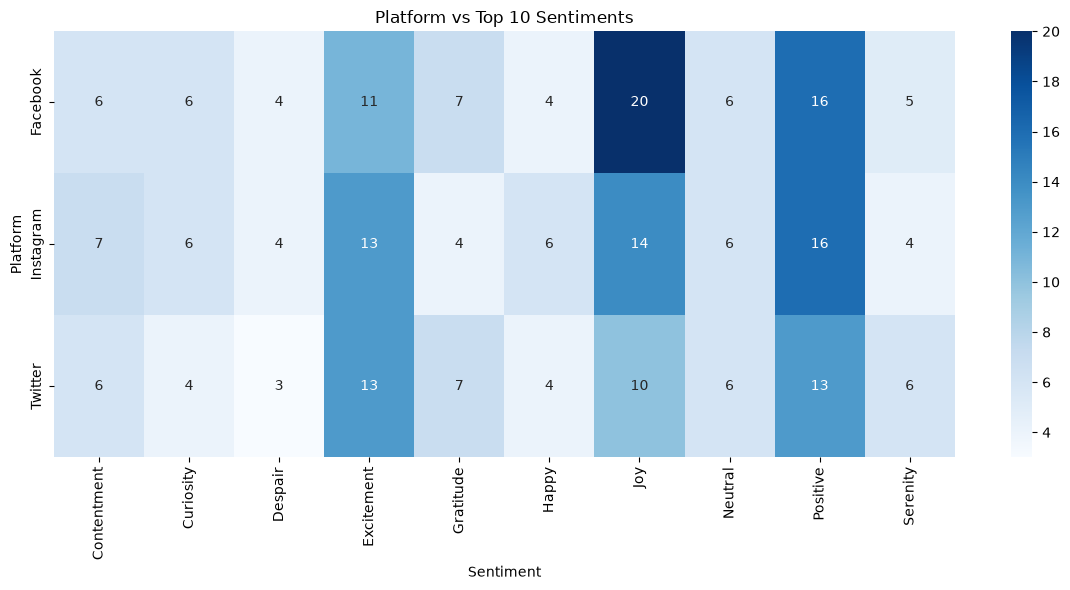

In [27]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    platform_sentiment_table,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Platform vs Top 10 Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Platform")

plt.tight_layout()
plt.show()


## Task 8 — Engagement Analysis

27. Compare average Likes by platform.

In [28]:
average_likes = (
    df.groupby("Platform")["Likes"]
    .mean()
    .sort_values(ascending=False)
)

print(average_likes)


Platform
Instagram    45.089147
Facebook     41.870130
Twitter      41.559671
Name: Likes, dtype: float64


28. Visualize average Likes by platform.

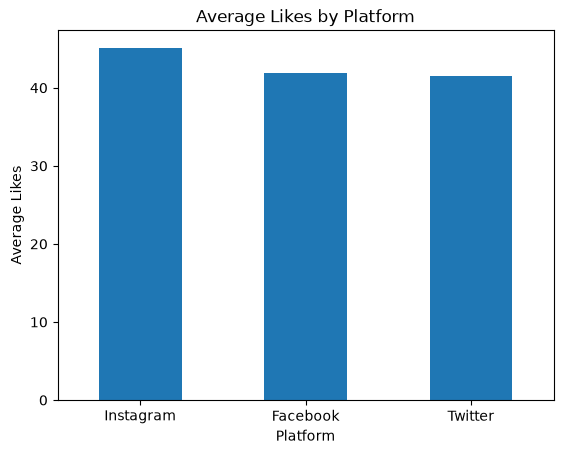

In [29]:
average_likes.plot(kind="bar")

plt.title("Average Likes by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Likes")
plt.xticks(rotation=0)

plt.show()


29. Compare average Retweets by platform.

In [30]:
average_retweets = (
    df.groupby("Platform")["Retweets"]
    .mean()
    .sort_values(ascending=False)
)

print(average_retweets)


Platform
Instagram    22.600775
Facebook     20.969697
Twitter      20.860082
Name: Retweets, dtype: float64


30. Visualize average Retweets by platform.

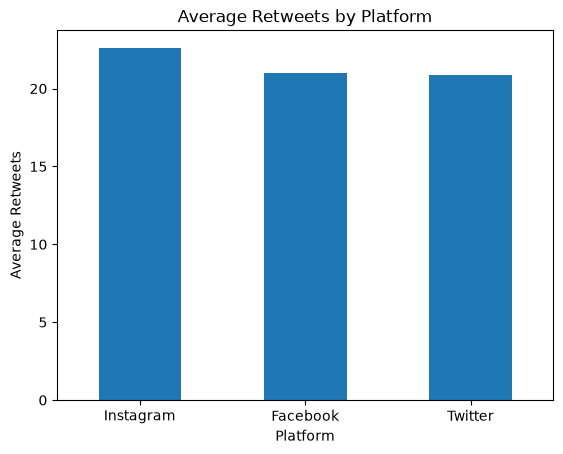

In [31]:
average_retweets.plot(kind="bar")

plt.title("Average Retweets by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Retweets")
plt.xticks(rotation=0)

plt.show()


31. Compare average Engagement by platform.

In [32]:
average_engagement = (
    df.groupby("Platform")["Engagement"]
    .mean()
    .sort_values(ascending=False)
)

print(average_engagement)


Platform
Instagram    67.689922
Facebook     62.839827
Twitter      62.419753
Name: Engagement, dtype: float64


32. Visualize average Engagement by platform.

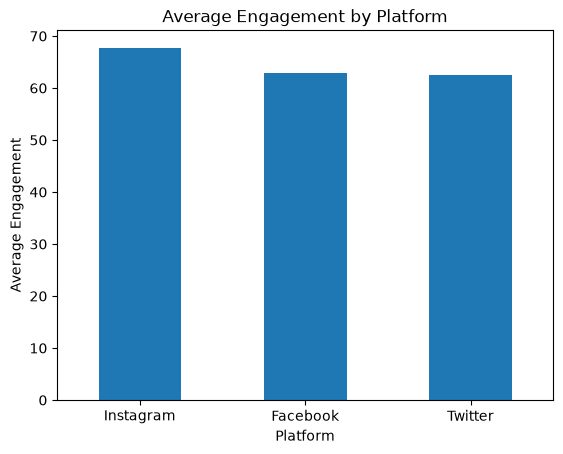

In [33]:
average_engagement.plot(kind="bar")

plt.title("Average Engagement by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Engagement")
plt.xticks(rotation=0)

plt.show()


## Task 9 — Country & Time Analysis

33. Find the top 10 countries by number of posts.

In [34]:
country_counts = df["Country"].value_counts().head(10)

print(country_counts)


Country
USA          188
UK           143
Canada       135
Australia     75
India         70
Brazil        17
France        16
Japan         15
Germany       14
Italy         11
Name: count, dtype: int64


34. Visualize the top 10 countries.

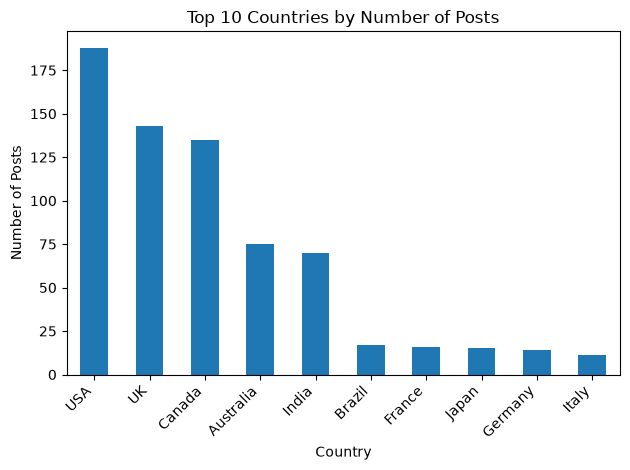

In [35]:
country_counts.plot(kind="bar")

plt.title("Top 10 Countries by Number of Posts")
plt.xlabel("Country")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


35. Analyze posts by month.

In [36]:
month_counts = df["Month"].value_counts().sort_index()

print(month_counts)


Month
1     82
2     85
3     44
4     51
5     46
6     71
7     62
8     78
9     77
10    48
11    49
12    39
Name: count, dtype: int64


36. Visualize the monthly trend.

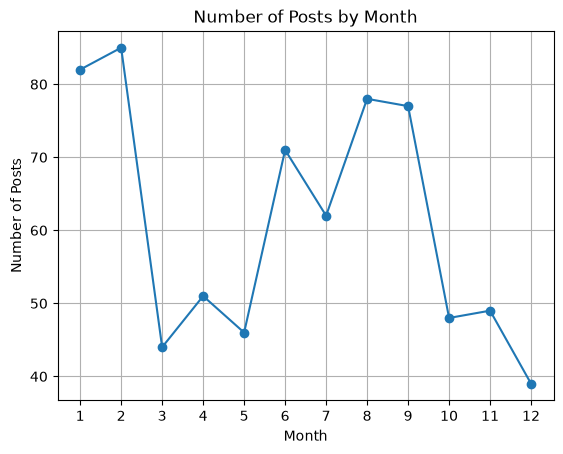

In [37]:
month_counts.plot(
    kind="line",
    marker="o"
)

plt.title("Number of Posts by Month")
plt.xlabel("Month")
plt.ylabel("Number of Posts")
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()


37. Analyze posts by hour.

In [38]:
hour_counts = df["Hour"].value_counts().sort_index()

print(hour_counts)


Hour
0      1
2      1
3      3
5      1
6      4
7      7
8     23
9     28
10    30
11    37
12    38
13    30
14    94
15    47
16    69
17    48
18    65
19    75
20    50
21    41
22    33
23     7
Name: count, dtype: int64


38. Visualize hourly activity.

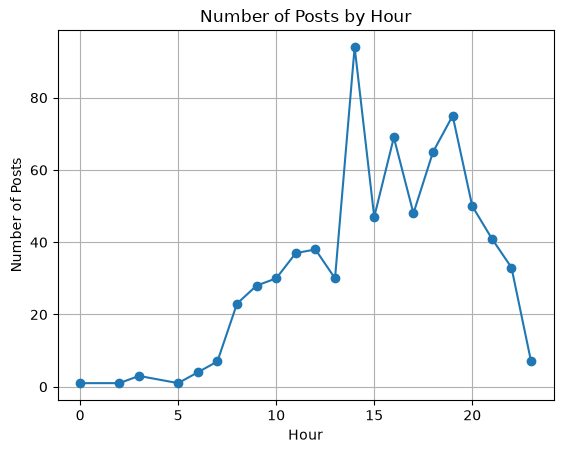

In [39]:
hour_counts.plot(
    kind="line",
    marker="o"
)

plt.title("Number of Posts by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Posts")
plt.grid(True)

plt.show()


## Task 10 — Find Highly Engaging Posts

39. Sort posts by Engagement to identify highly engaging records.

In [40]:
top_posts = df.sort_values(
    "Engagement",
    ascending=False
)

print(
    top_posts[
        ["Text", "Platform", "Sentiment", "Likes", "Retweets", "Engagement"]
    ].head(10)
)


                                                  Text   Platform  \
481  Surrounded by the colors of joy, a canvas pain...  Instagram   
530  Captivated by the spellbinding plot twists, th...    Twitter   
382  A sense of wonder at the vastness of the cosmo...  Instagram   
560  In the serene beauty of a sunset, nature unfol...  Instagram   
470  Dancing on sunshine, each step a celebration o...  Instagram   
550  After a series of defeats, the soccer team fac...    Twitter   
368  Elation over discovering a rare book in a quai...  Instagram   
540  Celebrating a historic victory in the World Cu...  Instagram   
355  Anticipation for an upcoming adventure in an e...    Twitter   
570  Underneath the city lights, the dancer express...    Twitter   

          Sentiment  Likes  Retweets  Engagement  
481             Joy   80.0      40.0       120.0  
530      Excitement   80.0      40.0       120.0  
382          Wonder   80.0      40.0       120.0  
560     Tranquility   80.0      40.0

40. Display the top 10 posts by Likes.

In [41]:
top_liked = df.sort_values(
    "Likes",
    ascending=False
)

print(
    top_liked[
        ["Text", "Platform", "Likes", "Retweets", "Engagement"]
    ].head(10)
)


                                                  Text   Platform  Likes  \
481  Surrounded by the colors of joy, a canvas pain...  Instagram   80.0   
530  Captivated by the spellbinding plot twists, th...    Twitter   80.0   
382  A sense of wonder at the vastness of the cosmo...  Instagram   80.0   
560  In the serene beauty of a sunset, nature unfol...  Instagram   80.0   
470  Dancing on sunshine, each step a celebration o...  Instagram   80.0   
550  After a series of defeats, the soccer team fac...    Twitter   80.0   
368  Elation over discovering a rare book in a quai...  Instagram   80.0   
540  Celebrating a historic victory in the World Cu...  Instagram   80.0   
355  Anticipation for an upcoming adventure in an e...    Twitter   80.0   
570  Underneath the city lights, the dancer express...    Twitter   80.0   

     Retweets  Engagement  
481      40.0       120.0  
530      40.0       120.0  
382      40.0       120.0  
560      40.0       120.0  
470      40.0       120

41. Display the top 10 posts by Retweets.

In [43]:
top_retweeted = df.sort_values(
    "Retweets",
    ascending=False
)

print(
    top_retweeted[
        ["Text", "Platform", "Likes", "Retweets", "Engagement"]
    ].head(10)
)


                                                  Text   Platform  Likes  \
570  Underneath the city lights, the dancer express...    Twitter   80.0   
470  Dancing on sunshine, each step a celebration o...  Instagram   80.0   
368  Elation over discovering a rare book in a quai...  Instagram   80.0   
540  Celebrating a historic victory in the World Cu...  Instagram   80.0   
560  In the serene beauty of a sunset, nature unfol...  Instagram   80.0   
355  Anticipation for an upcoming adventure in an e...    Twitter   80.0   
402  Awe-inspired by the vastness of the cosmos on ...  Instagram   80.0   
530  Captivated by the spellbinding plot twists, th...    Twitter   80.0   
382  A sense of wonder at the vastness of the cosmo...  Instagram   80.0   
432  Heartache deepens, a solitary journey through ...  Instagram   80.0   

     Retweets  Engagement  
570      40.0       120.0  
470      40.0       120.0  
368      40.0       120.0  
540      40.0       120.0  
560      40.0       120

42. Visualize the top 10 posts by Engagement.

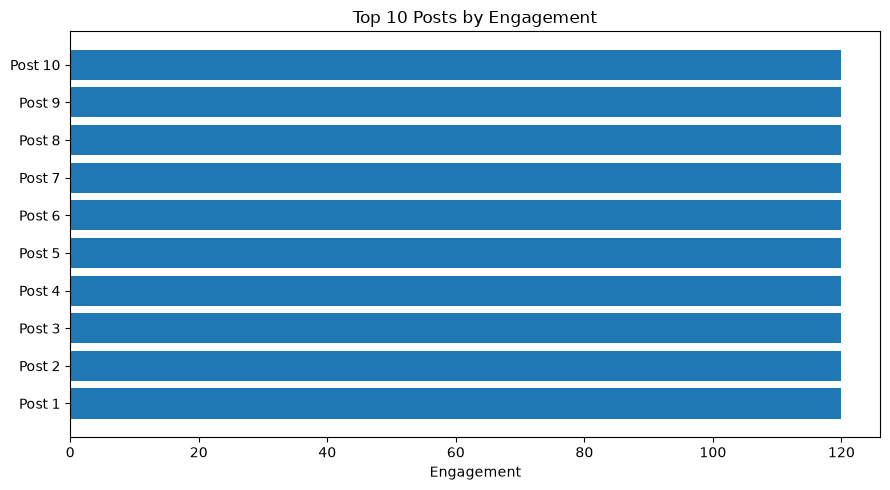

In [44]:
top_10_engagement = (
    df.nlargest(10, "Engagement")
    .sort_values("Engagement")
)

plt.figure(figsize=(9, 5))

plt.barh(
    range(len(top_10_engagement)),
    top_10_engagement["Engagement"]
)

plt.yticks(
    range(len(top_10_engagement)),
    [f"Post {i+1}" for i in range(len(top_10_engagement))]
)

plt.title("Top 10 Posts by Engagement")
plt.xlabel("Engagement")

plt.tight_layout()
plt.show()


## Task 11 — Correlation Analysis

43. Calculate correlations among Likes, Retweets, Engagement, and time-related numerical variables.

In [45]:
numeric_columns = [
    "Retweets",
    "Likes",
    "Year",
    "Month",
    "Day",
    "Hour",
    "Engagement"
]

correlation = df[numeric_columns].corr()

print(correlation)


            Retweets     Likes      Year     Month       Day      Hour  \
Retweets    1.000000  0.998482 -0.039982  0.073265  0.009213  0.196955   
Likes       0.998482  1.000000 -0.043415  0.066643  0.011489  0.195331   
Year       -0.039982 -0.043415  1.000000 -0.314845  0.021973 -0.087470   
Month       0.073265  0.066643 -0.314845  1.000000 -0.135873  0.137835   
Day         0.009213  0.011489  0.021973 -0.135873  1.000000  0.044072   
Hour        0.196955  0.195331 -0.087470  0.137835  0.044072  1.000000   
Engagement  0.999326  0.999831 -0.042283  0.068877  0.010733  0.195940   

            Engagement  
Retweets      0.999326  
Likes         0.999831  
Year         -0.042283  
Month         0.068877  
Day           0.010733  
Hour          0.195940  
Engagement    1.000000  


44. Visualize the correlation matrix using a heatmap.

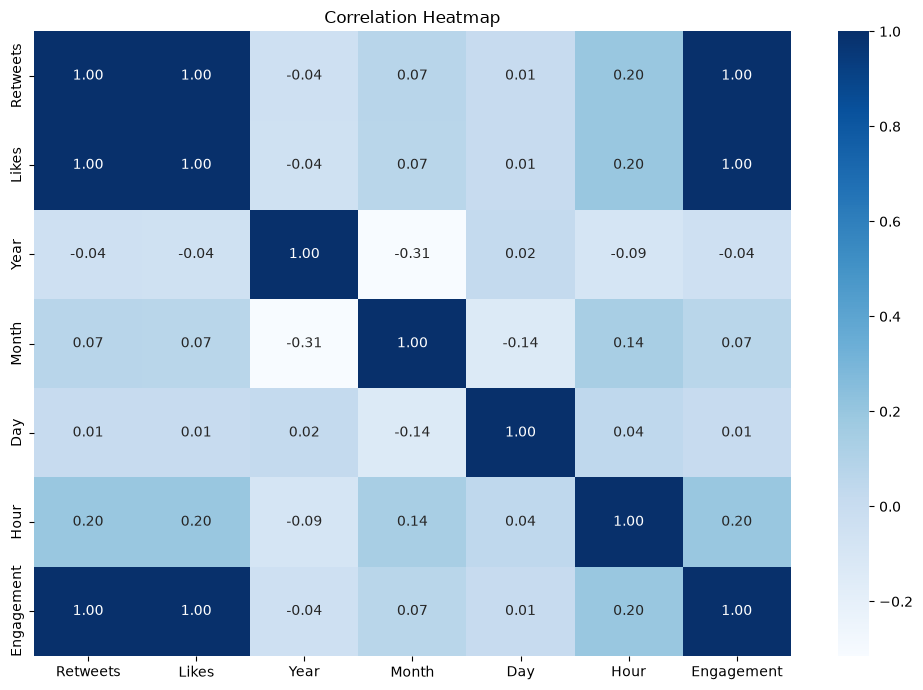

In [46]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.show()


## Task 12 — Hashtag Analysis

45. Extract and count the most frequently used hashtags.

In [47]:
from collections import Counter

hashtags = []

for value in df["Hashtags"].dropna():
    for tag in str(value).split(","):
        tag = tag.strip()
        if tag:
            hashtags.append(tag)

top_hashtags = Counter(hashtags).most_common(15)

print("Top 15 Hashtags:")

for hashtag, count in top_hashtags:
    print(hashtag, ":", count)


Top 15 Hashtags:
#Compassionate #TearsOfEmpathy : 3
#Proud #ScalingPeaks : 3
#Hopeful #SeedsOfOptimism : 3
#Playful #CarnivalEscapade : 3
#Love #SpreadLove : 2
#Shame #Injustice : 2
#Disgust #Corruption : 2
#Acceptance #LifeJourney : 2
#Frustration #EmotionalOutburst : 2
#Numbness #EmotionalShield : 2
#Confusion #ThoughtLabyrinth : 2
#Indifference #DriftingThroughLife : 2
#Numbness #EmotionalStorms : 2
#Inspired #CloudsOfCreativity : 2
#Contentment #TranquilWaters : 2


46. Visualize the top 15 hashtags.

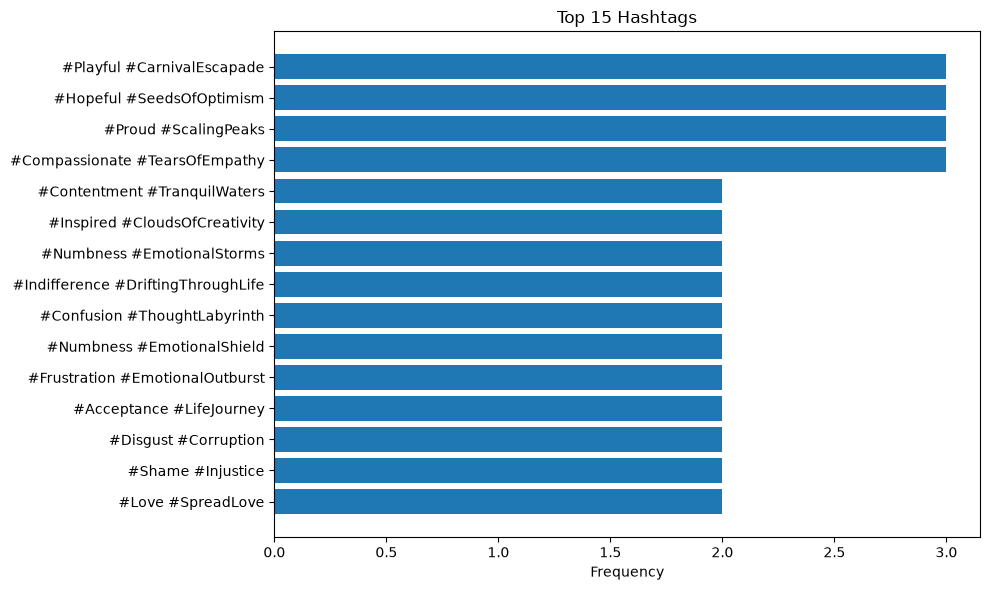

In [48]:
hashtag_df = pd.DataFrame(
    top_hashtags,
    columns=["Hashtag", "Count"]
)

hashtag_df = hashtag_df.sort_values("Count")

plt.figure(figsize=(10, 6))

plt.barh(
    hashtag_df["Hashtag"],
    hashtag_df["Count"]
)

plt.title("Top 15 Hashtags")
plt.xlabel("Frequency")

plt.tight_layout()
plt.show()


## Task 13 — Final Summary

47. Display the main project statistics.

In [49]:
print("========== SOCIAL MEDIA ANALYTICS SUMMARY ==========")

print("Total Posts:", len(df))
print("Total Likes:", int(df["Likes"].sum()))
print("Total Retweets:", int(df["Retweets"].sum()))
print("Total Engagement:", int(df["Engagement"].sum()))

print("Average Likes:", round(df["Likes"].mean(), 2))
print("Average Retweets:", round(df["Retweets"].mean(), 2))
print("Average Engagement:", round(df["Engagement"].mean(), 2))

print("Number of Platforms:", df["Platform"].nunique())
print("Number of Countries:", df["Country"].nunique())
print("Number of Sentiment Categories:", df["Sentiment"].nunique())


========== SOCIAL MEDIA ANALYTICS SUMMARY ==========
Total Posts: 732
Total Likes: 31404
Total Retweets: 15744
Total Engagement: 47148
Average Likes: 42.9
Average Retweets: 21.51
Average Engagement: 64.41
Number of Platforms: 3
Number of Countries: 33
Number of Sentiment Categories: 191


48. Display the final cleaned dataset.

In [50]:
print("Final dataset shape:", df.shape)
df.head(10)


Final dataset shape: (732, 14)


,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Engagement
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12,45.0
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8,15.0
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15,60.0
3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18,23.0
4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19,37.0
5,Feeling grateful for the little things in life.,Positive,2023-01-16 09:10:00,GratitudeNow,Twitter,#Gratitude #PositiveVibes,25.0,50.0,India,2023,1,16,9,75.0
6,Rainy days call for cozy blankets and hot cocoa.,Positive,2023-01-16 14:45:00,RainyDays,Facebook,#RainyDays #Cozy,10.0,20.0,Canada,2023,1,16,14,30.0
7,The new movie release is a must-watch!,Positive,2023-01-16 19:30:00,MovieBuff,Instagram,#MovieNight #MustWatch,15.0,30.0,USA,2023,1,16,19,45.0
8,Political discussions heating up on the timeline.,Negative,2023-01-17 08:00:00,DebateTalk,Twitter,#Politics #Debate,30.0,60.0,USA,2023,1,17,8,90.0
9,Missing summer vibes and beach days.,Neutral,2023-01-17 12:20:00,BeachLover,Facebook,#Summer #BeachDays,18.0,35.0,Australia,2023,1,17,12,53.0


49. Save the cleaned dataset so it can be reused in Assignment 2 and Assignment 3.

In [51]:
df.to_csv(
    "Clean_Social_Media_Sentiment_Dataset.csv",
    index=False
)

print("Clean dataset saved successfully.")


Clean dataset saved successfully.


## Conclusion

In this assignment, the Social Media Sentiment dataset was successfully analyzed using Python, Pandas, NumPy, Matplotlib, and Seaborn. The dataset was first inspected to understand its structure, columns, data types, missing values, and duplicate records.

The data was then cleaned by removing unnecessary index columns, trimming extra spaces from categorical fields, converting the Timestamp column into datetime format, and creating an Engagement metric from Likes and Retweets.

The analysis covered platform distribution, sentiment categories, engagement, country-wise activity, yearly and monthly trends, hourly activity, hashtags, highly engaging posts, and correlations among numerical variables. Multiple charts and heatmaps were used to present the results clearly.

Overall, the assignment provides practical experience in data profiling, data cleaning, exploratory data analysis, statistical analysis, and data visualization using a real social-media dataset.

### Expected Dataset Facts

For the supplied CSV, the initial dataset contains **732 rows and 15 columns**. After removing the two unnecessary index columns and adding the Engagement column, the working dataset contains **732 rows and 14 columns**. The dataset has no missing values and no exact duplicate rows. The raw Sentiment field contains many labels, so the original categories are preserved rather than forcing them into only three classes.